# IMT 573 - Final Examination


Points: 100

Name: Rebecca Ko

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Rebecca Ko

November 23, 2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import random

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [22]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [23]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [24]:
affairs.describe()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991


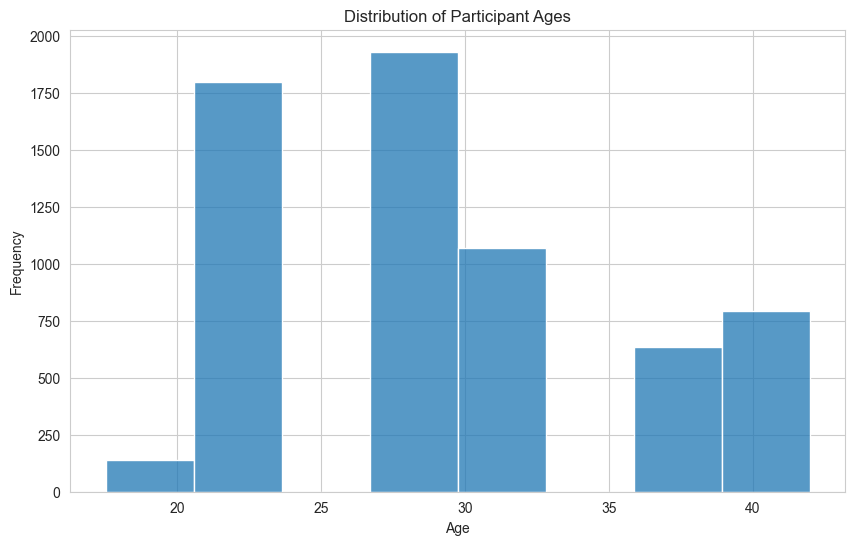

In [25]:
#Plot participant age
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

sns.histplot(
    data = affairs,
    x = 'age',
    binwidth = 3
)

plt.title("Distribution of Participant Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Participant Occupation breakdown: 
occupation
3.0    2783
4.0    1834
2.0     859
5.0     740
6.0     109
1.0      41
Name: count, dtype: int64


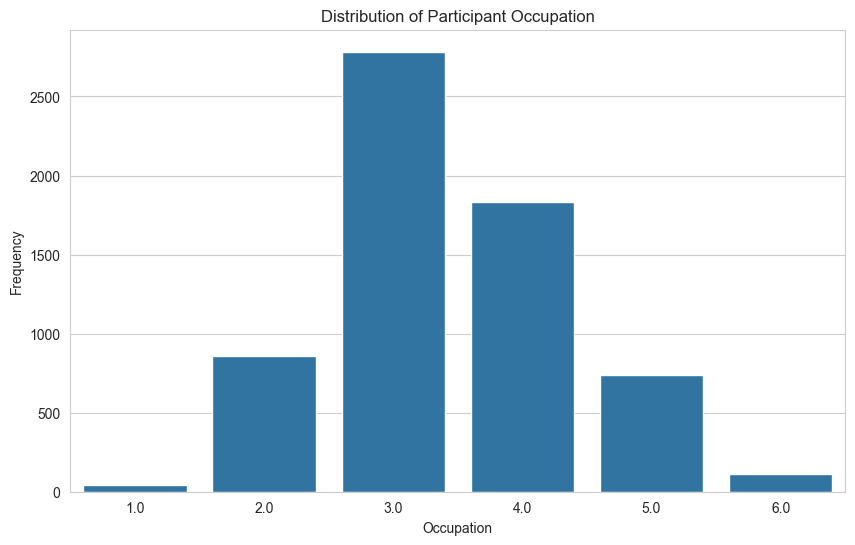

Occupation is coded from 1 to 6. Each category can be found above in the description at the top.


In [26]:
#Find most frequently listed occupation
print(f"Participant Occupation breakdown: \n{affairs['occupation'].value_counts()}")

#Plot participant occupation
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

sns.countplot(
    data = affairs,
    x = 'occupation'
)

plt.title("Distribution of Participant Occupation")
plt.xlabel("Occupation")
plt.ylabel("Frequency")
plt.show()

print('Occupation is coded from 1 to 6. Each category can be found above in the description at the top.')

Participant education breakdown: 
educ
14.0    2277
12.0    2084
16.0    1117
17.0     510
20.0     330
9.0       48
Name: count, dtype: int64


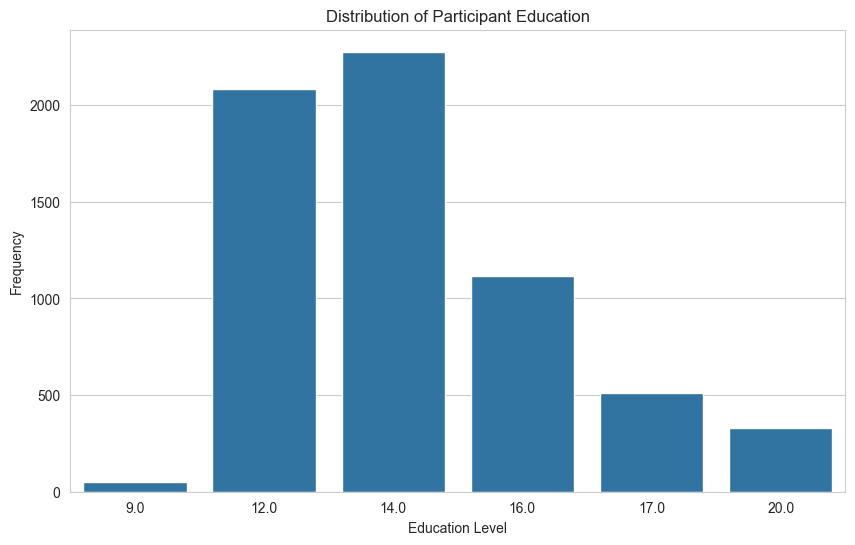

Education is coded.
9 represents completion of grade school. 12 represents completion of high school. 14 represents completion of some college.
16 represents completion of college. 17 represents some completion of graduate school. Lastly,20 represents completion of an advanced degree.


In [27]:
#Find most frequently listed education level
print(f"Participant education breakdown: \n{affairs['educ'].value_counts()}")

#Plot participant education level
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

sns.countplot(
    data = affairs,
    x = 'educ'
)

plt.title("Distribution of Participant Education")
plt.xlabel("Education Level")
plt.ylabel("Frequency")
plt.show()

print("Education is coded.")
print("9 represents completion of grade school. 12 represents completion of high school. 14 represents completion of some college.")
print("16 represents completion of college. 17 represents some completion of graduate school. Lastly,20 represents completion of an advanced degree.")


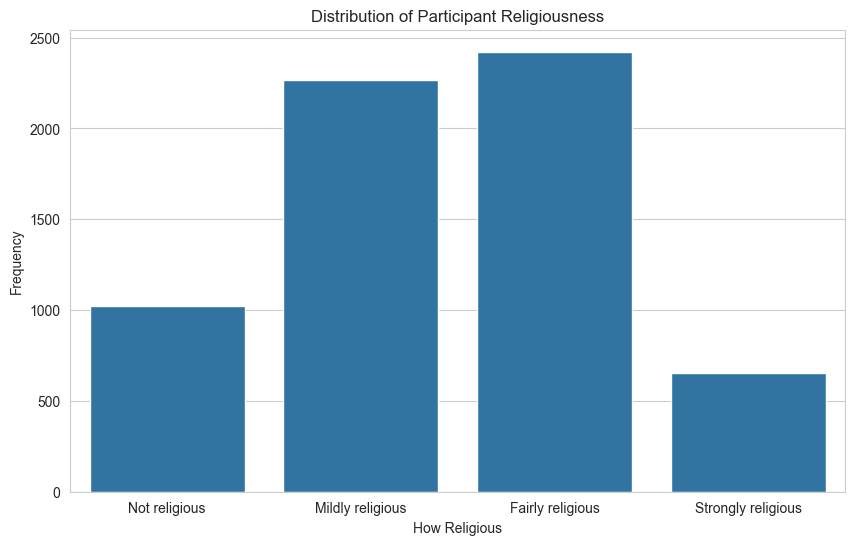

In [28]:
#Find most frequently listed religion level
#affairs['religious'].value_counts()

religionMap = {
    1 : "Not religious",
    2 : "Mildly religious",
    3 : "Fairly religious",
    4 : "Strongly religious"
}

affairs['religiousness'] = affairs['religious'].astype(int).map(religionMap)

#Plot participant religion level
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

sns.countplot(
    data = affairs,
    x = 'religiousness',
    order = ["Not religious", "Mildly religious", "Fairly religious", "Strongly religious"]
)

plt.title("Distribution of Participant Religiousness")
plt.xlabel("How Religious")
plt.ylabel("Frequency")
plt.show()


**Summary/Response**

Based on the data summary, the average age of respondents is 29.1 years, and the average number of children is 1.4. 

Since the dataset contains highly sensitive personal information, including marital satisfaction, extramarital behavior, and religiousness, the data is deeply private, and there are ethical and privacy concerns. While the data is technically anonymized because no names are attached, many potential attributes could still be used to identify a person. Additionally, the dataset has the potential to create stigma since the data models the likelihood of engaging in an extramarital affair based on demographic characteristics. For example, it could create a stigma that married men at a certain age and level of religion are more likely to have an affair. This potential prediction can be pretty insensitive and harmful.

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [29]:
#Create new column indicating if person had an affair or not
affairs['hadAffair'] = affairs['affairs'].apply(lambda x : 1 if x > 0 else 0)

**Response**

The advantage of this approach is that it can simplify the modeling of the data and create easily identifiable groups. By splitting the data into "had an affair" and "didn't have an affair," it can be easier to answer the question of whether someone had an affair or not. However, by simplifying the data, we lose information. For example, we lose information about how many affairs someone had, and people who had one affair versus 10 affairs are indistinguishable within the data. The simplicity could affect the model's performance; if a large proportion of participants had at least one affair, the model might overestimate the likelihood that an individual has an affair. Such predictions could reinforce harmful stereotypes or stigmas if interpreted insensitively. 

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [30]:
#Code adjusted from previous assignment 'IMT_573_ps8_prediction_rko.ipynb'
#Copy data just in case
affairsReg = affairs.copy()
affairsReg['hadAffair'] = affairs['affairs'].apply(lambda x : 1 if x > 0 else 0)

#Convert categorical columns to categories
categoryColumns = ['rate_marriage', 'religious', 'educ', 'occupation', 'occupation_husb']
for col in categoryColumns:
    affairsReg[col] = affairsReg[col].astype('category')

#Build logistic regression formula
formula = "hadAffair ~ age + yrs_married + children + C(rate_marriage) + C(religious) + C(educ) + C(occupation) + C(occupation_husb)"

#Calculate logistic regression
logisticRegressionModel = smf.logit(formula = formula, data = affairsReg).fit()

#Print regression summary
print(logisticRegressionModel.summary())

Optimization terminated successfully.
         Current function value: 0.540499
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              hadAffair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6340
Method:                           MLE   Df Model:                           25
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1403
Time:                        20:30:06   Log-Likelihood:                -3440.8
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.501e-221
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     1.1597      0.643      1.805      0.071      -0.

**Summary**

The logistic regression results indicate several characteristics are predictive of having an affair. The characteristics were judged based on their p-values, with p-values < 0.05 indicating statistical significance. The coefficient was examined to determine whether the variable predicted taking part in an affair. Higher marriage ratings (3, 4, 5) and higher levels of religion are associated with a lower likelihood of having an affair. Meanwhile, the longer a couple is married, the possibility of an affair increases. It can also be seen that older participants are less likely to participate in an affair. When the participant's occupation level is 5 or 6, the likelihood of an affair also increases. However, any other level of occupation or husband's occupation does not seem to be a significant predictor. All other variables also do not seem to show any statistically significant effect on having an affair. These findings suggest that marriage rating, religiousness, age, years married, and a high-level participant occupation are the strongest covariates in predicting whether a participant engages in an affair.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [31]:
#List all predictors
predictors = ['age', 'yrs_married', 'children', 'C(rate_marriage)', 'C(religious)', 'C(educ)', 'C(occupation)', 'C(occupation_husb)']

#Base model creation and rating
bestAic = float('inf')
bestModel = None
bestFormula = "hadAffair ~ 1"

#Forward stepwise selection
remainingPredictors = predictors.copy()
selectedPredictors = []

while remainingPredictors:
    aicWithCandidates = []

    #Testing predictors and finding best aic 
    for predictor in remainingPredictors:
        #Build formula for potential predictor
        potentialFormula = "hadAffair ~ " + "+".join(selectedPredictors + [predictor])

        #Fit logistic regression model
        potentialModel = smf.logit(formula = potentialFormula, data = affairsReg).fit()

        #Store info to compare
        aicWithCandidates.append((potentialModel.aic, predictor, potentialModel))

    #Find lowest AIC
    aicWithCandidates.sort()
    bestPotentialAic, bestPotentialPredictor, bestPotentialModel = aicWithCandidates[0]

    #Check if best aic, and if so replace current items in the proper variables
    if bestPotentialAic < bestAic:
        bestAic = bestPotentialAic
        bestModel = bestPotentialModel
        print(f"Added {bestPotentialPredictor} with AIC = {bestPotentialAic:.2f}")
        #Make sure to add predictor to "selected" list so formula changes accordingly and get new AIC values with determined predictors included
        selectedPredictors.append(bestPotentialPredictor)
        remainingPredictors.remove(bestPotentialPredictor)
    else:
        break

#Print out best model
print("Best model formula: ")
print("hadAffair ~ " + " + ".join(selectedPredictors))
print(f"Regression Summary: \n{bestModel.summary()}")
print(f"AIC of Model: {bestAic}")

Optimization terminated successfully.
         Current function value: 0.618131
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.608507
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.616224
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.573183
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619397
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.623844
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.622601
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.627208
         Iterations 5
Added C(rate_marriage) with AIC = 7307.76
Optimization terminated successfully.
         Current function value: 0.566380
         Iterations 5
Optimization terminated successfully.
  

**Summary**

The final model I settled on was based on the AIC value when different predictors were added to my logistic regression model formula. Based on the AIC values, the final model included six of the eight predictors. The variables included are rate_marriage, yrs_married, religious, occupation, age, and educ. 

(e) Interpret the model parameters using the model from part (d).

Based on the model in part d, yrs_married and age are significant predictors of having an affair as their p-values are less than 0.01. That said, based on the coefficients, longer marriages are associated with higher odds of an affair occurring, while older age is associated with lower odds of an affair occurring. Rate_marriage, specifically 3, 4, and 5, and religious level predictors are also significant as their p-values are less than 0.01. Higher marriage satisfaction ratings and higher religiousness reduce the likelihood of the participant having an affair. While not all occupations are statistically significant, occupation levels five and six have a p-value less than 0.05, indicating their significance in predicting having an affair. With the higher occupation levels, the chance of an affair increases. While education did lead to a lower AIC during model creation, its levels were not statistically significant in the resulting model. 

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

In [32]:
#Number of artificial entries in dataset
n = 100

random.seed(42)

#Create dataset
artificialData = pd.DataFrame({
    'rate_marriage' : np.random.choice([1, 2, 3, 4, 5], size = n),
    'age' : affairs['age'].mean(), 
    'yrs_married' : affairs['yrs_married'].mean(), 
    'religious' : int(affairs['religious'].mean()), 
    'educ' : int(affairs['educ'].mean()), 
    'occupation' : int(affairs['occupation'].mean()), 
})

#Set category columns
categoryColumns = ['rate_marriage', 'religious', 'educ', 'occupation']
for col in categoryColumns:
    artificialData[col] = artificialData[col].astype('category')

artificialData['predictProbability'] = bestModel.predict(artificialData)

#Mean probability of affair by marriage rating
probabilityByRating = artificialData.groupby('rate_marriage', observed = True)['predictProbability'].mean()
probabilityByRating = probabilityByRating.reset_index()
print(f"Probability of Affair by Marriage Rating: \n{probabilityByRating}")

Probability of Affair by Marriage Rating: 
  rate_marriage  predictProbability
0             1            0.774014
1             2            0.685508
2             3            0.603019
3             4            0.385763
4             5            0.232727


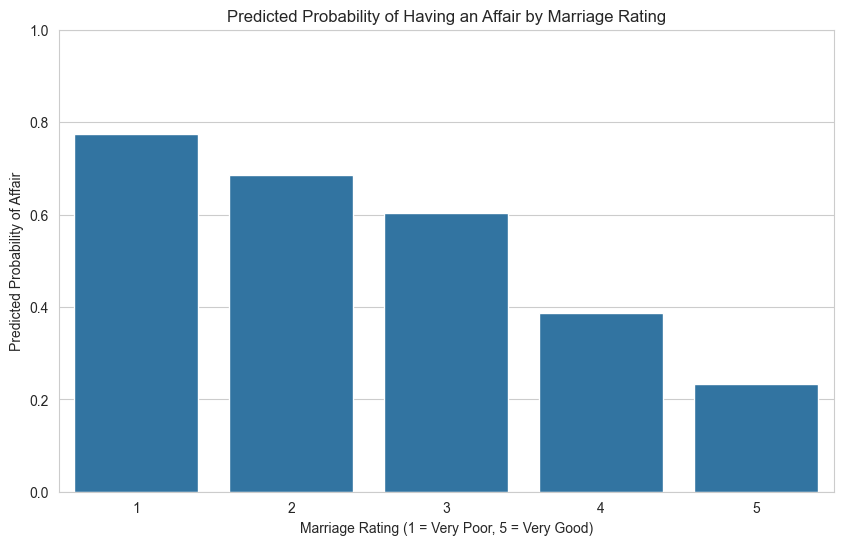

In [33]:
#Create visualization
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

sns.barplot(
    data = probabilityByRating,
    x = 'rate_marriage',
    y = 'predictProbability'
)
plt.title('Predicted Probability of Having an Affair by Marriage Rating')
plt.xlabel('Marriage Rating (1 = Very Poor, 5 = Very Good)')
plt.ylabel('Predicted Probability of Affair')
plt.ylim(0, 1)
plt.show()

**Summary**

Since all other variables in the artificial dataset were held constant at their mean values, the predicted probabilities show the effect of marriage quality on the likelihood of the participant having an affair. The graph above shows a decrease in probability as the marriage rating increases. This indicates that individuals who report a poorer marriage rating have a higher predicted probability of engaging in an affair. It can also be seen that once a marriage rating has achieved "good" and "very good," the probability decreases substantially compared to the probability difference between a "very poor" and "poor" rating. 

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

Working with the affairs dataset, I still have the same concerns I raised early on about how sensitive the information collected is. Even without names, combinations of all the attributes collected could still be used to re-identify individuals, especially if the population was small. 

A concern that was raised after I created the logistic regression model was the nature of the prediction being made. Modeling the probability of having an affair based on demographic characteristics risks generating stigmas. While statistical relationships do not imply causation, when people outside statistics look at the numbers, they begin to make causal assumptions. Additionally, with the frequency of affairs switched to a Boolean, we could have oversimplified the data, and our results may be misleading. 

Overall, while the analysis demonstrates valuable techniques for statistical modeling, it also helped me understand the need for responsible handling of sensitive data and the need to cautiously interpret predictive models, especially those that can lead to long-term consequences. 

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [34]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

**Question**

Is there a relationship between a player's number of runs batted during their career and their salary?

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [35]:
Hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [36]:
Hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

**Summary**

After examining the dataset a little bit, one major issue is that the Salary variable has missing values. The salary column contains only 263 non-null values, even though there are 322 entries in the dataset. Since my analysis focuses on runs batted during a player's career and salary, I cannot use entries in the dataset without salary. I will be removing the observation entries without salary, so I have complete data for both variables of interest. There are no missing variables from the CRBI variable, so I will not need to clean the data further than removing rows without a salary. 

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

In [37]:
#Clean data
hitterData = Hitters.dropna(subset = ['Salary'])

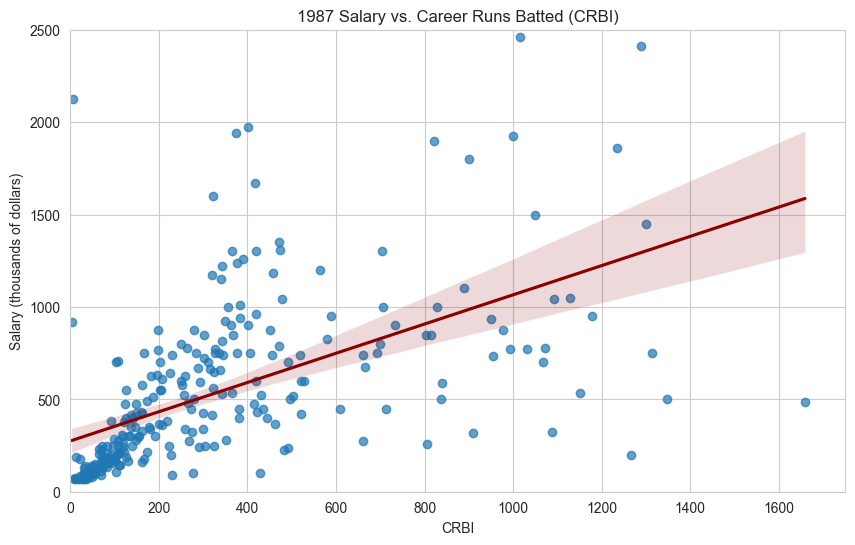

In [38]:
#Create visualization 1
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

sns.regplot(
    data = hitterData,
    x = 'CRBI',
    y = 'Salary',
    scatter_kws = {'alpha' : 0.7},
    line_kws = {'color' : 'darkred'}
)

plt.title('1987 Salary vs. Career Runs Batted (CRBI)')
plt.xlabel('CRBI')
plt.ylabel('Salary (thousands of dollars)')
plt.xlim([0, 1750])
plt.ylim([0, 2500])
plt.show()

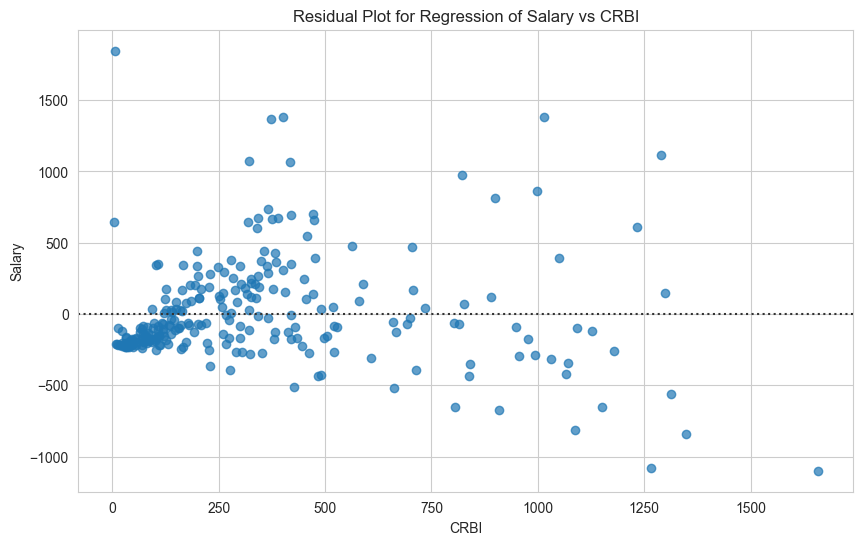

In [39]:
#Create visualization 2
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

sns.residplot(
    data = hitterData,
    x = 'CRBI',
    y = 'Salary',
    scatter_kws = {'alpha' : 0.7}
)
plt.title('Residual Plot for Regression of Salary vs CRBI')
plt.show()

**Summary**

After cleaning my data, I analyzed the data to answer my original question by using a regression plot and a residual plot. 

My regression plot shows a positive linear relationship between CRBI and salary, meaning players with a higher number of runs batted during their career tend to earn a higher salary. In the regression plot, the data points are tightly clustered at low CRBI and low salary values, but the positively sloped regression line suggests a general positive association between the two variables. There are several outliers in the dataset, such as a player with less than 500 CRBI and a salary over $2000k. This indicates there could be other variables that contribute to a player's salary than career runs batted. 

I followed the regression plot with a residual plot to help evaluate how well CRBI as a variable can explain the salary of a player. Most residuals fall between -500 and 500, but there are some points far outside of the range, landing below -1000 and above 1000. This pattern suggests that the linear model used at the beginning doesn't fully capture the variability in salary between players. The residual plot shows that as CRBI increases, the residuals become more spread out, so it shows that as CRBI increases, player salary varies more, and so CRBI is not the only factor contributing to these evaluations of salary. 

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

I was able to properly answer all the questions listed in this problem. I think my research question was defined well enough that I could answer with the provided dataset. However, the dataset did have some limitations. Mostly, the fact that the Salary variable was missing multiple entries. This reduced my sample size by 59 entries. 
Based on my analysis, player salary is influenced by factors beyond CRBI, so my regression line plot cannot fully and accurately predict player salary. However, a general trend was evident. The current data may be able to help understand what other variables contribute to a player's salary, but there may also be more variables not recorded within this dataset, as sports always seem to have many factors.  

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [40]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

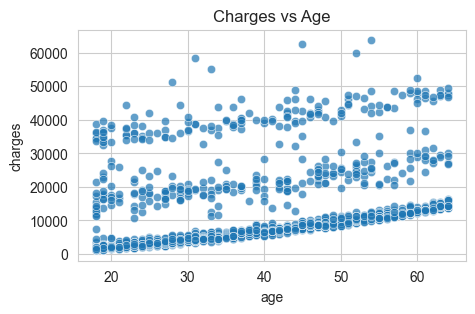

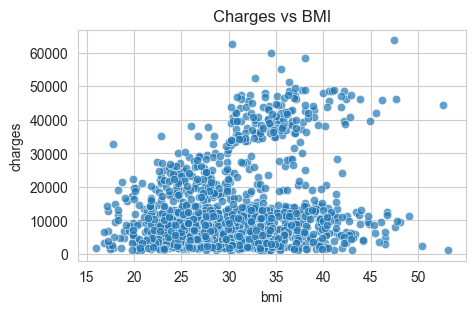

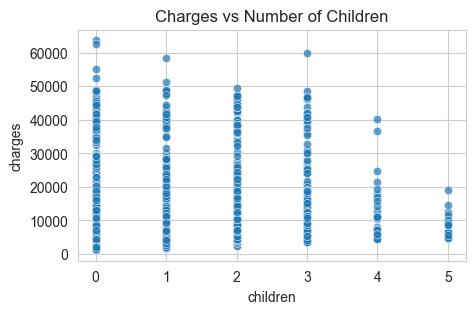

,Variable,Corr
0,age,0.299008
1,bmi,0.198341
2,children,0.067998


In [41]:
#Numerical value relationship exploration

resultList1 = []

#age vs charges
resultList1.append({
    'Variable' : 'age',
    'Corr' : df['charges'].corr(df['age'])
})
#plot
plt.figure(figsize=(5, 3))
sns.set_style('whitegrid')
sns.scatterplot(
    data = df,
    x = 'age',
    y = 'charges',
    alpha = 0.7
)
plt.title('Charges vs Age')
plt.show()
#-----------------------------------------------------------------------------------------#
#bmi vs charges
resultList1.append({
    'Variable' : 'bmi',
    'Corr' : df['charges'].corr(df['bmi'])
})
#plot
plt.figure(figsize=(5, 3))
sns.set_style('whitegrid')
sns.scatterplot(
    data = df,
    x = 'bmi',
    y = 'charges',
    alpha = 0.7
)
plt.title('Charges vs BMI')
plt.show()
#-----------------------------------------------------------------------------------------#
#children vs charges
resultList1.append({
    'Variable' : 'children',
    'Corr' : df['charges'].corr(df['children'])
})
#plot
plt.figure(figsize=(5, 3))
sns.set_style('whitegrid')
sns.scatterplot(
    data = df,
    x = 'children',
    y = 'charges',
    alpha = 0.7
)
plt.title('Charges vs Number of Children')
plt.show()

resultDF = pd.DataFrame(resultList1)
resultDF

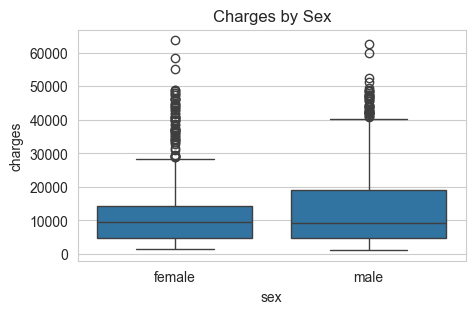

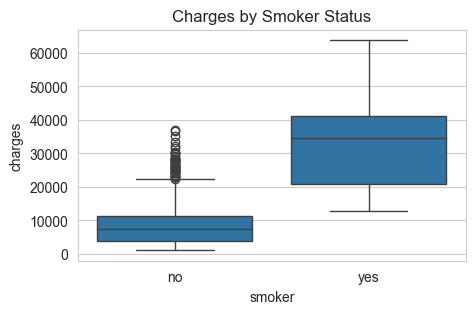

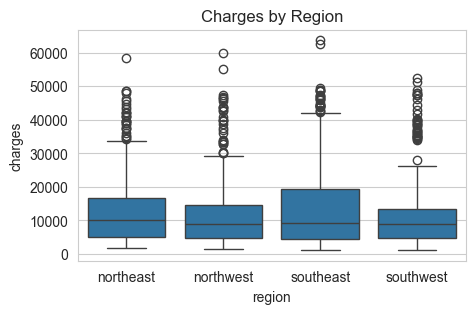

,Variable,R-Squared,F p-value
0,sex,0.003282,3.613272e-02
1,smoker,0.619765,8.271436e-283
2,region,0.006634,3.089336e-02


In [42]:
#Categorical relationship exploration

#Change type of variables from object to categorical
catVariables = ['sex', 'smoker', 'region']

for col in catVariables:
    df[col] = df[col].astype('category')
    
resultList2 = []

#charges vs sex
formula1 = "charges ~ C(sex)"
model1 = smf.ols(formula = formula1, data = df).fit()
resultList2.append({
    'Variable' : 'sex',
    'R-Squared' : model1.rsquared,
    'F p-value' : model1.f_pvalue
})
#plot
plt.figure(figsize=(5, 3))
sns.set_style('whitegrid')
sns.boxplot(
    data = df,
    x = 'sex',
    y = 'charges',
)
plt.title('Charges by Sex')
plt.show()

#-----------------------------------------------------------------------------------------#
#charges vs smoker
formula2 = "charges ~ C(smoker)"
model2 = smf.ols(formula = formula2, data = df).fit()
resultList2.append({
    'Variable' : 'smoker',
    'R-Squared' : model2.rsquared,
    'F p-value' : model2.f_pvalue
})
#plot
plt.figure(figsize=(5, 3))
sns.set_style('whitegrid')
sns.boxplot(
    data = df,
    x = 'smoker',
    y = 'charges',
)
plt.title('Charges by Smoker Status')
plt.show()

#-----------------------------------------------------------------------------------------#
#charges vs region
formula3 = "charges ~ C(region)"
model3 = smf.ols(formula = formula3, data = df).fit()
resultList2.append({
    'Variable' : 'region',
    'R-Squared' : model3.rsquared,
    'F p-value' : model3.f_pvalue
})
#plot
plt.figure(figsize=(5, 3))
sns.set_style('whitegrid')
sns.boxplot(
    data = df,
    x = 'region',
    y = 'charges',
)
plt.title('Charges by Region')
plt.show()

#-----------------------------------------------------------------------------------------#
resultDF = pd.DataFrame(resultList2)
resultDF

**Summary**

The correlations between charges and numerical variables were all positive and below 0.05. This indicates a weak linear relationship and that none of the numerical variables (age, BMI, and children) can strongly explain the variation in charges. However, all categorical variables had p-values less than 0.05, with smoker status being closest to 0. The R-squared value for smoker status is 0.6, further demonstrating a strong relationship with charges. This relationship is also reflected in the box plot, showing that smokers clearly have higher charges. For sex and region, while the p-value is less than 0.05, the R-squared values are close to zero. This suggests that these variables do not explain the variation in charges, especially when compared with the R-squared value for smoker status. 

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [43]:
#Fit multiple linear regression model
formulaAll = 'charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)'
fullModel = smf.ols(formula = formulaAll, data = df).fit()
#Get R-squared of full multiple linear regression model
fullRSquared = fullModel.rsquared
#Multiple linear regression model excluding bmi
formulaNoBMI = 'charges ~ age + children + C(sex) + C(smoker) + C(region)'
noBMIModel = smf.ols(formula = formulaNoBMI, data = df).fit()
#Get R-squared of multiple linear regression model that doesn't have bmi
noBMIRSquared = noBMIModel.rsquared
#Variance explained by bmi
varianceExplained = fullRSquared - noBMIRSquared
print(f"Variance explained by BMI: {varianceExplained}")

Variance explained by BMI: 0.02636361495171946


In [54]:
# Full model with all predictors
full_model = smf.ols('charges ~ age + bmi + children + C(sex) + smoker + C(region)', data=df).fit()
# Model without BMI
reduced_model = smf.ols('charges ~ age + children + C(sex) + smoker + C(region)', data=df).fit()
# Calculate partial R² for BMI
ss_full = full_model.ssr
ss_reduced = reduced_model.ssr
partial_r2_bmi = (ss_reduced - ss_full) / ss_reduced
print(f"Partial R² for BMI: {partial_r2_bmi:.4f}")

Partial R² for BMI: 0.0957


(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

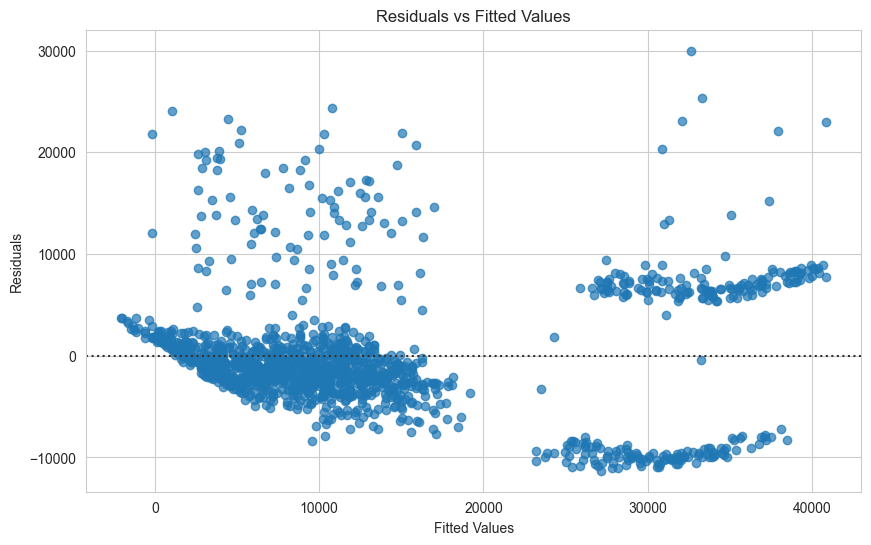

In [44]:
#Create residual plot
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

#plot fitted values vs residuals
sns.residplot(
    x = fullModel.fittedvalues,
    y = fullModel.resid,
    scatter_kws = {'alpha' : 0.7}
)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

**Summary**

Based on my basic residuals plot, I see that as my fitted values increase, the residual spread increases and splits into two "bands". This would mean my assumption of constant variance is violated, and therefore my model is less reliable the larger the fitted value. So as charges increase, my model's errors will become more apparent. However, my model does seem to predict lower fitted values (low-cost charges) fairly well, as the residuals are clustered around 0. 

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [45]:
#List all predictors
predictors = ['age', 'bmi', 'children', 'C(sex)', 'C(smoker)', 'C(region)']

#Base model creation and rating
bestAic = float('inf')
bestModel = None
bestFormula = "charges ~ 1"

#Forward stepwise selection
remainingPredictors = predictors.copy()
selectedPredictors = []

while remainingPredictors:
    aicWithCandidates = []

    #Testing predictors and finding best aic 
    for predictor in remainingPredictors:
        #Build formula for potential predictor
        potentialFormula = "charges ~ " + "+".join(selectedPredictors + [predictor])

        #Fit logistic regression model
        potentialModel = smf.ols(formula = potentialFormula, data = df).fit()

        #Store info to compare
        aicWithCandidates.append((potentialModel.aic, predictor, potentialModel))

    #Find lowest AIC
    aicWithCandidates.sort()
    bestPotentialAic, bestPotentialPredictor, bestPotentialModel = aicWithCandidates[0]

    #Check if best aic, and if so replace current items in the proper variables
    if bestPotentialAic < bestAic:
        bestAic = bestPotentialAic
        bestModel = bestPotentialModel
        print(f"Added {bestPotentialPredictor} with AIC = {bestPotentialAic:.2f}")
        #Make sure to add predictor to "selected" list so formula changes accordingly and get new AIC values with determined predictors included
        selectedPredictors.append(bestPotentialPredictor)
        remainingPredictors.remove(bestPotentialPredictor)
    else:
        break

bestFormula = "charges ~ " + " + ".join(selectedPredictors)
#Print out best model
print("Best model formula: ")
print(bestFormula)
print(f"Regression Summary: \n{bestModel.summary()}")
print(f"AIC of Model: {bestAic}")

Added C(smoker) with AIC = 27665.46
Added age with AIC = 27251.32
Added bmi with AIC = 27121.84
Added children with AIC = 27112.04
Added C(region) with AIC = 27111.66
Best model formula: 
charges ~ C(smoker) + age + bmi + children + C(region)
Regression Summary: 
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     572.7
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:30:07   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1330   BIC:                         2.715e+04
Df Model:                           7                                         
Covariance Type:         

**Summary**

The "best" fit model I produced through a forward stepwise selection process was similar but not identical to my full model from part (b). My best-fit model included almost all variables except for sex. This suggests that sex does not play a big part in predicting medical charges when the other variables are included. 

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [46]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

columnNames = [
    'sample_code_number',
    'clump_thickness',
    'uniformity_of_cell_size',
    'uniformity_of_cell_shape',
    'marginal_adhesion',
    'single_epithelial_cell_size',
    'bare_nuclei',
    'bland_chromatin',
    'normal_nucleoli',
    'mitoses',
    'class'
]
fullLink = location + dataframe
breastCancerData = pd.read_csv(fullLink, header=None, index_col = False, names = columnNames)

In [47]:
breastCancerData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   sample_code_number           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_of_cell_size      699 non-null    int64 
 3   uniformity_of_cell_shape     699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitoses                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [48]:
breastCancerData.head()

,sample_code_number,clump_thickness,uniformity_of_cell_size,uniformity_of_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


**Summary**

The dataset contains 11 variables and 699 entries. Sample_code_number represents the ID for the records and is an integer. Clump_thickness, uniformity_of_cell_size, uniformity_of_cell_shape, marginal_adhesion, single_epithelial_cell_size, bland_chromatin, normal_nucleoli, and mitoses are integer values to describe the record sample and are numbers 1-10. Class is to indicate whether the sample is benign or malignant, represented by a 2 or 4, respectively. Bare_nuclei is supposed to be a value between 1 and 10; however, the data type is object.

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [49]:
#Check for values 1-10
checkColumns = [
    'clump_thickness',
    'uniformity_of_cell_size',
    'uniformity_of_cell_shape',
    'marginal_adhesion',
    'single_epithelial_cell_size',
    'bare_nuclei',
    'bland_chromatin',
    'normal_nucleoli',
    'mitoses'
]
breastCancerData[checkColumns].agg(['min', 'max'])

,clump_thickness,uniformity_of_cell_size,uniformity_of_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses
min,1,1,1,1,1,1,1,1,1
max,10,10,10,10,10,?,10,10,10


In [50]:
breastCancerData['class'].unique()

array([2, 4])

**Summary**

For most of the data, it seems that there are no missing values at first glance since the info provides that every variable has 699 non-null entries. However, it can be seen that bare_nuclei has a max of '?', which is not what is expected.  

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [51]:
#Code adjusted from previous assignment 'IMT_573_ps8_prediction_rko.ipynb'
#Clean data
breastCancerData = breastCancerData[breastCancerData['bare_nuclei'] != '?'].copy()
breastCancerData['bare_nuclei'] = breastCancerData['bare_nuclei'].astype(int)

np.random.seed(42)
shuffledIndices = np.random.permutation(len(breastCancerData))

#Split the dataset
trainingSize = int(0.7 * len(breastCancerData))
trainingIndices = shuffledIndices[:trainingSize]
testingIndices = shuffledIndices[trainingSize:]

trainingData = breastCancerData.iloc[trainingIndices]
testingData = breastCancerData.iloc[testingIndices].copy()

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [52]:
#Code adjusted from previous assignment 'IMT_573_ps8_prediction_rko.ipynb'
#Classification Model: Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

#Separate features and target
XTrain = trainingData.drop(columns = ['class'])
yTrain = trainingData['class']

XTest = testingData.drop(columns = ['class'])
yTest = testingData['class']

#Train Naive Bayes model and predict
naiveBayesModel = GaussianNB()
naiveBayesModel.fit(XTrain, yTrain)
yPredict = naiveBayesModel.predict(XTest)

#Confusion Matrix
confusionMatrixNB = confusion_matrix(yTest, yPredict)

print(confusionMatrixNB)

[[106  26]
 [ 16  57]]


**Summary**

Through a Naive Bayes model, the confusion matrix provided that TN = 106, TP = 57, FP = 26, and FN = 16. Out of the errors, FP and FN, the most problematic type in this dataset would be FN. False negatives in this case would mean my model predicted the sample to be benign when, in fact, it was malignant. This means actual cancer was missed, which is extremely dangerous. While a false positive means the model predicted the sample to be malignant when it was actually benign and counts as an error, it is safer than missing a malignant tumor. 

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

Spam filtering classification can be useful in helping sort emails into spam or the general inbox. It can be further extended to help users sort emails into different categories, such as social or promotions. Some predictors could be email subject, content, and sender email.

Healthcare diagnoses classification can help predict certain diseases or results based on blood tests and vital signs. The goal would be to predict an individual's disease based on the patient's collected health data. With proper data, it would be possible to at least narrow down diagnoses and help doctors make quicker, more accurate diagnoses. 

The semiconductor fab classification can be useful, as uptime, throughput, and yield are essential. The model could be used to predict delay vs. no delay, and maybe even the general duration of delay. Some predictors for this could include engineer comments, state transitions, time of day, material type, and recipe. Classification in a fab can also be used for inference to understand what potentially increases the likelihood of delays and can help with improving operations.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

A regression of air quality could be useful for the general public's health. Some predictors may be temperature, wind, humidity, vehicle exhaust in a certain city, and industrial activity. The goal is mainly for predictions, as it could help forecast the air quality for the next day, for individuals to look at and maybe prepare themselves for. It could also be used for inference to identify factors that may be strongly affecting air quality, since society often talks about taking a green initiative to reduce global warming. 

Health risk regression for certain diseases, for example, for diabetes. Some predictors could be BMI, age, blood pressure, and blood glucose. The goal of this application would be mostly predictive. The goal of this regression would be to help individuals detect if they are on the path to diabetes early on, so it can be avoided to the best of the individual's ability. It could be used for inference if you were to test various factors, as I know those I listed are not the only contributing factors to an individual being diagnosed with diabetes. 

A regression model could also be used to determine the appropriate tank volume for a marine animal. Some predictors could be animal length, weight, species, and activity level. The goal of this model would be prediction, since the model would help estimate how large an individual or aquarium would need to house different animals safely. 

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

The advantages of a very flexible statistical model are that it can provide a better fit for non-linear relationships and reduce bias. The disadvantage of a very flexible statistical model is the increased risk of overfitting and the need for more data to improve model accuracy. A more flexible model would be best when you are trying to predict an outcome accurately, and the result is expected to be complex and non-linear. 

The advantages of a less flexible statistical model are the results are easier to interpret and can be used with a smaller sample size. The disadvantages are a higher risk of bias and a poor estimate if an incorrect statistical model is selected for the dataset. A less flexible model might be preferred when you have fewer data points to work with and when one is trying to just understand a basic relationship between two variables. For example, we often used linear regression to examine whether the general trend was that, if the predictor increased, the outcome would decrease or increase, and to determine whether the relationship we observed was significant. 

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.


Male Salary = $50+20*$GPA$+0.07*$IQ$+0.01*($GPA$*$IQ$)$

Female Salary = $50+20*$GPA$+0.07*$IQ$+35+0.01*($GPA$*$IQ$)-10*$GPA

Assuming GPA and IQ are fixed, the difference between salaries is

Female Salary - Male Salary = $35-10*$GPA

From this equation, when GPA is 3.5, the salary is the same regardless of gender. When GPA is greater than 3.5, the male salary is predicted to be greater than the female salary. When GPA is below 3.5, then the female salary is predicted to be greater than the male salary.  

**The correct answer is iii.**

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

Least Squares Function = $50+20*$GPA$+0.07*$IQ$+35*$Gender$+0.01*($GPA$*$IQ$)-10*($GPA$*$Gender$)$

Salary for a female with an IQ of 110 and a GPA of 4 = $50+20*4+0.07*110+35*1+0.01*(4*110)-10*(4*1)$ = 137.1 (in thousands of dollars)

Salary for a female with an IQ of 110 and a GPA of 4 = $50 + 80 + 7.7 + 35 + 4.4 - 40$

Salary for a female with an IQ of 110 and a GPA of 4 = $137,100

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

I believe the statement is false. Even if the coefficient is small, it does not determine how significant a predictor is; it shows only the scale and trend of the relationship. There are other ways to check for an interaction effect; one often mentioned is whether the p-value is less than 0.05 or even 0.01 to determine the significance of a relationship. Another way would be to look at confidence intervals of the predictos to help determine if the interaction term is significant. 

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [53]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

NameError: name 'get_songs' is not defined

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  